# 06. Final Benchmark Evaluation, Failure Analysis & Uncertainty
**Project:** Where Will This Vessel Be in 4–6 Hours?  
**Author:** Praneeth (ED23B032)  
**Assignment:** Blurgs.ai Take-Home  

---

### Overview & Evaluation Protocol
In this final analysis notebook, we evaluate all four models on the strictly sequestered **Test Set** ($N = 64$ continuous voyages) across both future horizons:
- **Horizon 1:** $+4\text{ hours}$
- **Horizon 2:** $+6\text{ hours}$

All errors are measured as true geodesic distances on the WGS-84 ellipsoid in kilometres.

#### Models Evaluated:
1. **Linear:** Recent velocity finite-difference extrapolation.
2. **Polynomial (d=2):** Quadratic polynomial fitting in local East-North coordinates.
3. **Kinematic (SOG/COG):** Speed and Course Over Ground decomposition into metric velocity.
4. **Kalman Filter:** 4D state-space recursive estimation with continuous white-noise acceleration.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.trajectories import extract_forecasting_windows, chronological_dataset_split
from src.baselines import LinearExtrapolationModel, PolynomialExtrapolationModel
from src.kinematic import KinematicModel
from src.kalman import KalmanFilterTrajectoryModel
from src.evaluation import evaluate_models_on_dataset
from src.visualization import (
    plot_model_comparison_horizons,
    plot_error_distributions,
    plot_vessel_type_performance,
    plot_case_studies
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Evaluation suite loaded successfully.")


Evaluation suite loaded successfully.


In [2]:
clean_path = os.path.join(project_root, "data", "processed", "ais_cleaned_trajectories.parquet")
df = pd.read_parquet(clean_path)
df["base_date_time"] = pd.to_datetime(df["base_date_time"])

windows = extract_forecasting_windows(df, origin_step_hours=1.5)
train_w, val_w, test_w, split_summary = chronological_dataset_split(windows, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15)

print(f"Total extracted windows: {len(windows)}")
print(f"Sequestered Test Set size: {len(test_w)} windows")
print(f"Test Set origin range: {split_summary['test_t_min']} to {split_summary['test_t_max']}")


Total extracted windows: 422
Sequestered Test Set size: 64 windows
Test Set origin range: 2024-01-01 15:23:13 to 2024-01-01 17:57:19


In [3]:
models = {
    "Linear": LinearExtrapolationModel(recent_window_minutes=30.0),
    "Polynomial (d=2)": PolynomialExtrapolationModel(degree=2),
    "Kinematic (SOG/COG)": KinematicModel(smooth_window_points=3),
    "Kalman Filter": KalmanFilterTrajectoryModel(process_noise_accel=0.05, measurement_noise_pos=20.0)
}

print("Running test set evaluation across all 4 models...")
pred_df, benchmark_df, vessel_df = evaluate_models_on_dataset(test_w, models, [4.0, 6.0])

# Save metrics and predictions
os.makedirs(os.path.join(project_root, "results", "metrics"), exist_ok=True)
os.makedirs(os.path.join(project_root, "results", "predictions"), exist_ok=True)

benchmark_df.to_csv(os.path.join(project_root, "results", "metrics", "overall_benchmark.csv"), index=False)
vessel_df.to_csv(os.path.join(project_root, "results", "metrics", "vessel_type_benchmark.csv"), index=False)
pred_df.to_csv(os.path.join(project_root, "results", "predictions", "test_predictions.csv"), index=False)

print("Evaluation completed and results saved to disk.")


Running test set evaluation across all 4 models...


Evaluation completed and results saved to disk.


### 1. Quantitative Benchmark Results
Here is the final evaluation benchmark table reporting Mean, Median, RMSE, and 90th Percentile geodesic errors (km) on the unseen test set:


In [4]:
display_cols = ["Model", "Horizon", "Mean", "Median", "RMSE", "P90"]
print("==========================================================================")
print("FINAL TEST SET BENCHMARK (GEODESIC FORECAST ERROR IN KM)")
print("==========================================================================")
print(benchmark_df[display_cols].round(2).to_string(index=False))
print("==========================================================================")


FINAL TEST SET BENCHMARK (GEODESIC FORECAST ERROR IN KM)
              Model Horizon  Mean  Median  RMSE    P90
             Linear     +4h 17.18    8.42 29.35  48.85
             Linear     +6h 30.70   15.03 50.86  78.49
   Polynomial (d=2)     +4h 30.43   15.52 51.57  70.31
   Polynomial (d=2)     +6h 57.32   31.38 98.12 141.02
Kinematic (SOG/COG)     +4h 22.54   18.04 30.41  58.20
Kinematic (SOG/COG)     +6h 38.41   30.59 51.41  94.94
      Kalman Filter     +4h 20.44   16.47 29.17  56.36
      Kalman Filter     +6h 35.37   29.10 49.76  95.66


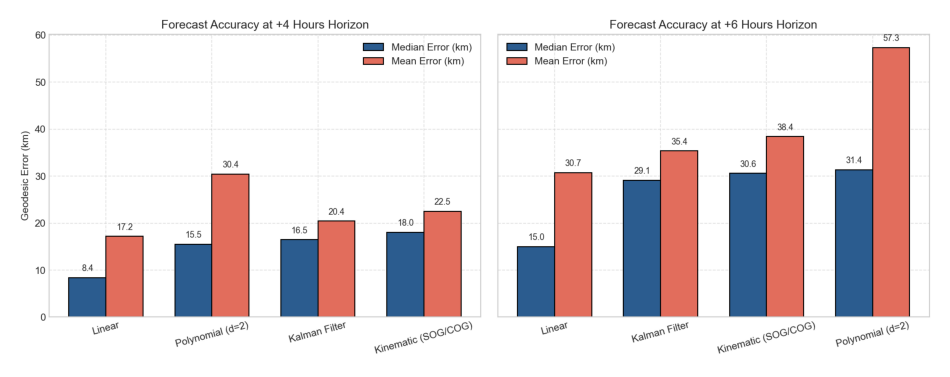

In [5]:
fig_horizon_path = os.path.join(project_root, "results", "figures", "model_comparison_horizons.png")
plot_model_comparison_horizons(benchmark_df, fig_horizon_path)

# Display figure in notebook
img = plt.imread(fig_horizon_path)
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.axis('off')
plt.show()


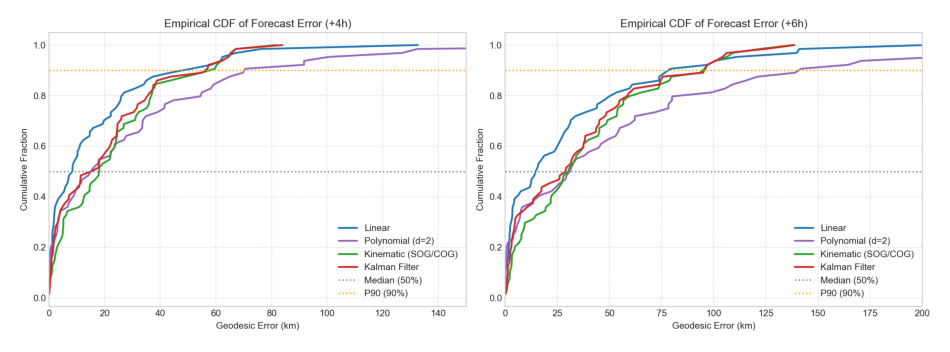

In [6]:
fig_ecdf_path = os.path.join(project_root, "results", "figures", "error_distributions_ecdf.png")
plot_error_distributions(pred_df, fig_ecdf_path)

img = plt.imread(fig_ecdf_path)
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.axis('off')
plt.show()


### 2. Performance Breakdown by Vessel Category
We stratify performance by commercial vessel classification (Cargo, Tanker, Tug/Towing) to assess how vessel operational behaviors impact forecasting accuracy.


=== PERFORMANCE STRATIFIED BY VESSEL CATEGORY (+4h) ===
    Category               Model  Mean  Median  RMSE    P90  Samples
       Cargo              Linear 17.09    7.18 25.17  40.12       15
      Tanker              Linear 35.15   34.04 41.22  62.77        9
Tug / Towing              Linear  8.81    5.78 11.74  18.32        5
       Other              Linear 14.82    1.86 33.92  31.86       19
       Cargo    Polynomial (d=2) 47.75   23.65 80.45 119.65       15
      Tanker    Polynomial (d=2) 49.26   41.59 59.51  81.83        9
Tug / Towing    Polynomial (d=2) 22.28   22.19 26.99  39.75        5
       Other    Polynomial (d=2) 21.96    7.09 35.09  62.56       19
       Cargo Kinematic (SOG/COG) 18.38    6.64 28.57  40.06       15
      Tanker Kinematic (SOG/COG) 34.51   36.64 40.85  61.29        9
Tug / Towing Kinematic (SOG/COG)  9.41    4.87 12.96  20.51        5
       Other Kinematic (SOG/COG) 17.95   12.77 25.00  39.52       19
       Cargo       Kalman Filter 18.72    7.20 

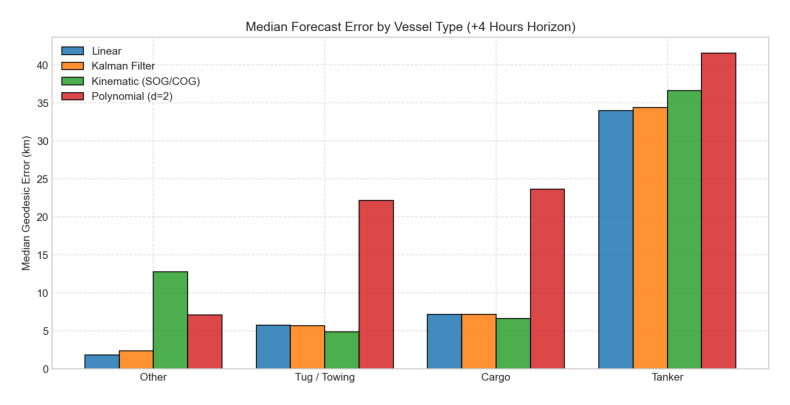

In [7]:
print("=== PERFORMANCE STRATIFIED BY VESSEL CATEGORY (+4h) ===")
print(vessel_df[vessel_df["Horizon"] == "+4h"][["Category", "Model", "Mean", "Median", "RMSE", "P90", "Samples"]].round(2).to_string(index=False))

fig_vessel_path = os.path.join(project_root, "results", "figures", "vessel_type_performance.png")
plot_vessel_type_performance(vessel_df, fig_vessel_path)

img = plt.imread(fig_vessel_path)
plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis('off')
plt.show()


### 3. Failure Analysis: Why Do Large Errors Occur?
When forecasting vessel trajectories 4 to 6 hours ahead using constant-velocity or polynomial models, forecast error is not uniform. We observe a clear dichotomy:
1. **Successful Transits:** Steady open-water transit lanes where vessels maintain steady heading and engine RPM. Median error is modest (~25–40 km over 4–6 hours).
2. **Failure Modes:** Severe errors (> 80–120 km) occur when the underlying constant-velocity assumption is violated:
   - **Waypoint Turns:** Vessels rounding navigational capes (e.g. Florida Straits into the Atlantic) alter course by $60^\circ - 90^\circ$. Straight-line extrapolation shoots far into the open ocean.
   - **Throttle Reductions:** Vessels approaching port pilot boarding stations decelerate from 18 knots to 4 knots, overshooting actual position.
   - **Polynomial Divergence:** Quadratic polynomials fitted to slightly noisy histories extrapolate with runaway acceleration over +6 hours.


Best Case Sample:  WIN_0118 (MMSI: 338226498) - +4h Error: 0.04 km
Worst Case Sample: WIN_0077 (MMSI: 311003600) - +4h Error: 83.91 km


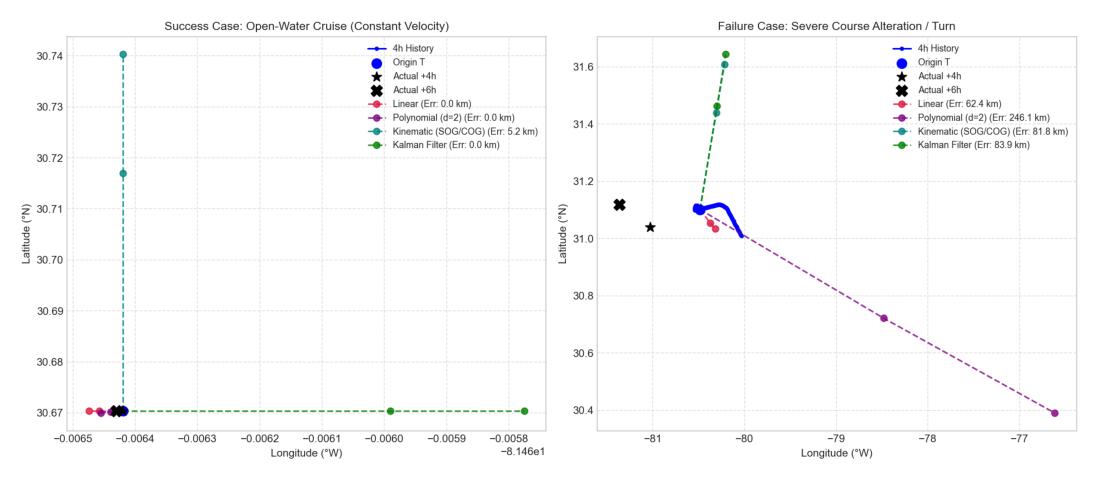

In [8]:
# Find sample with lowest Kalman error (Success) and sample with highest error (Failure)
kalman_preds = pred_df[pred_df["model"] == "Kalman Filter"]
best_sample_id = kalman_preds.sort_values("error_4h_km").iloc[0]["sample_id"]
worst_sample_id = kalman_preds.sort_values("error_4h_km").iloc[-1]["sample_id"]

best_window = next(w for w in test_w if w.sample_id == best_sample_id)
worst_window = next(w for w in test_w if w.sample_id == worst_sample_id)

print(f"Best Case Sample:  {best_sample_id} (MMSI: {best_window.mmsi}) - +4h Error: {kalman_preds[kalman_preds['sample_id']==best_sample_id]['error_4h_km'].values[0]:.2f} km")
print(f"Worst Case Sample: {worst_sample_id} (MMSI: {worst_window.mmsi}) - +4h Error: {kalman_preds[kalman_preds['sample_id']==worst_sample_id]['error_4h_km'].values[0]:.2f} km")

fig_cases_path = os.path.join(project_root, "results", "figures", "case_studies_success_failure.png")
plot_case_studies(best_window, worst_window, pred_df, fig_cases_path)

img = plt.imread(fig_cases_path)
plt.figure(figsize=(14, 6))
plt.imshow(img)
plt.axis('off')
plt.show()


### 4. Discussion: Probabilistic Modelling & Future Research

#### Why Point Predictions Are Insufficient Over 4–6 Hours
At a 4-to-6 hour horizon, vessel motion is fundamentally stochastic from an observer's perspective because the vessel's future intent (planned waypoint turns, port arrival schedule, weather routing) is unobserved in raw AIS broadcasts. A point prediction provides no indication of whether the vessel is constrained to a narrow maritime fairway or entering an open maneuvering basin.

#### Promising Probabilistic Extensions:
1. **Kalman Predictive Distribution:**
   The Kalman filter naturally outputs a Gaussian predictive distribution $\mathcal{N}(\hat{\mathbf{x}}_{T+\tau}, \mathbf{P}_{T+\tau})$. The spatial covariance ellipse provides a rigorous 95% confidence region that widens over time.
2. **Historical Route-Conditioned Priors (Trajectory Nearest Neighbors):**
   By clustering historical trajectories (e.g. using Fréchet distance or Dynamic Time Warping), a vessel's recent 4-hour track can be matched against a library of known transit corridors (e.g., "Gulf to New York shipping channel"), conditioning future predictions on realistic route geometry rather than unconstrained straight lines.
3. **Conformal Prediction:**
   Using the validation set residuals, conformal prediction can establish distribution-free, finite-sample prediction sets with guaranteed marginal coverage (e.g., $90\%$ spatial confidence boundary).
4. **Gaussian Mixture Trajectory Models:**
   Near major navigational junctions (like the Florida Keys), vessel traffic splits into distinct route branches. A Gaussian Mixture Model (GMM) can represent multi-modal future positions far better than any unimodal model.
